# All-or-None Network Growth Model

Code accompanying *Densification and structural transitions in the
all-or-none copying model*. Each section reproduces one of the
analytical results or figures from the paper, plus a few supplementary
simulations.

## Contents

1. Helpers, caching, and model implementation
2. Number of links (paper Sec. II A, Fig. 2)
3. Fluctuations and self-averaging (paper Sec. II B)
4. Degree distribution (paper Sec. III, Fig. 3)
5. Triangles and clique hierarchy (paper Sec. IV)
6. Clustering and average shortest-path distance (paper Sec. V; Figs. 4 and 5)
7. Degree assortativity (paper Sec. VI, Fig. 6)
8. Phase diagram (paper summary)
9. Spectral radius (bonus)

## Figure map

| Notebook cell | Content | Paper counterpart |
|---|---|---|
| 5  | $\langle L_N \rangle$ vs $p$                                       | **Fig. 2** |
| 5  | Sparse-regime mean degree $2\langle L_N\rangle / N$               | supplementary |
| 7  | $\mathrm{CV}(L_N)$ vs $N$ for AoN and independent copying          | supplementary |
| 7  | Distribution of $L_N$ at a representative $(N, p)$                 | supplementary |
| 9  | Degree CCDF $\Pr(K \ge k)$                                         | **Fig. 3** |
| 11 | $\langle T_N \rangle$ vs $N$ (triangle recursion check)            | supplementary |
| 11 | $\langle K_m(N) \rangle$ vs $N$ (clique hierarchy illustration)    | supplementary |
| 13 | Transitivity $\tau_N$ and local clustering $\bar c_N$ vs $p$       | **Fig. 4** |
| 14 | $\langle \ell_N \rangle$ vs $N$                                    | **Fig. 5** |
| 16 | Degree assortativity $r$ vs $p$                                    | **Fig. 6** |
| 18 | Phase-diagram schematic                                            | summary of Fig. 1 |
| 20 | $\langle \lambda_1 \rangle$ vs $p$ and attack curves               | bonus (not in paper) |

## Recommended workflow

- Run in `MODE = "fast"` first.
- Switch to `MODE = "paper"` for the final figures.
- Theory is plotted as lines; simulation as symbols.

## Caching

Every simulation cell wraps its heavy loop in `cached_compute(...)`, which stores results under `cache/` next to this notebook. The first run of a cell takes the full simulation time; every later run with the same parameters loads the cached `.npz` file and returns instantly. If you want to reproduce the figures without re-running the simulations, please use the provided `cache/` folder and ensure it is kept in the same directory as this notebook; otherwise, delete it to recompute from scratch.



In [56]:

%matplotlib inline

from __future__ import annotations

import json
import hashlib
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from scipy.special import gammaln, digamma
from scipy.stats import t as student_t
from scipy.sparse.linalg import eigsh


# ------------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------------
MODE = "paper"          # "paper" for slower / nicer final runs
                        # change to "fast" for quick checks
SAVE_FIGS = False       # set to True to export PDF + PNG into FIG_DIR
BASE_SEED = 2026

FIG_DIR = Path("figures")
CACHE_DIR = Path("cache")
FIG_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

EULER_GAMMA = 0.5772156649015328606
MARKERS = ["o", "s", "^", "D", "v", "P", "X"]
LINESTYLES = ["-", "--", "-.", ":"]

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "mathtext.fontset": "cm",
    "axes.grid": False,
    "grid.alpha": 0.5,
    "grid.linewidth": 0.8,
    "grid.color": "#bbbbbb",
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
})


@dataclass(frozen=True)
class Config:
    N_links: tuple
    n_real_links: int
    p_links_sim: tuple
    N_deg: int
    n_real_deg: int
    p_deg: tuple
    N_tri: int
    n_real_tri: int
    p_tri: tuple
    N_assort: int
    n_real_assort: int
    p_assort: tuple
    N_path: tuple
    n_real_path: int
    p_path: tuple
    N_fluc: tuple
    n_real_fluc: int
    p_fluc: tuple
    N_hist: int
    p_hist: float
    n_hist: int
    N_lambda: int
    n_real_lambda: int
    p_lambda: tuple
    N_attack: int
    p_attack: float
    n_remove_attack: int
    n_random_attack: int
    n_real_ccdf: int
    n_real_cluster: tuple


def make_config(mode: str) -> Config:
    if mode == "paper":
        return Config(
            N_links=(200, 1000, 3000),
            n_real_links=10,
            p_links_sim=(0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1.0),
            N_deg=5000,
            n_real_deg=10,
            p_deg=(0.10, 0.25, 0.40),
            N_tri=1600,
            n_real_tri=14,
            p_tri=(0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.33, 0.36, 0.40, 0.45),
            N_assort=(500, 2000, 10000),
            n_real_assort=20,
            p_assort=(0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
            N_path=(200, 500, 1000, 2000, 5000),
            n_real_path=20,
            p_path=(0.0, 0.3, 0.6, 0.9, 1.0),
            N_fluc=(150, 300, 600, 1200),
            n_real_fluc=50,
            p_fluc=(0.40, 0.70),
            N_hist=1000,
            p_hist=0.70,
            n_hist=120,
            N_lambda=600,
            n_real_lambda=8,
            p_lambda=(0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90, 1.00),
            N_attack=320,
            p_attack=0.65,
            n_remove_attack=15,
            n_random_attack=20,
            n_real_ccdf=10,
            n_real_cluster=(10, 5, 1),
        )

    return Config(
        N_links=(200, 800, 2000),
        n_real_links=6,
        p_links_sim=(0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0),
        N_deg=3500,
        n_real_deg=6,
        p_deg=(0.10, 0.25, 0.40),
        N_tri=1200,
        n_real_tri=8,
        p_tri=(0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.33, 0.36, 0.40, 0.45),
        N_assort=(500, 2000, 10000),
        n_real_assort=10,
        p_assort=(0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
        N_path=(200, 500, 1000, 2000, 5000),
        n_real_path=8,
        p_path=(0.0, 0.3, 0.6, 0.9, 1.0),
        N_fluc=(150, 300, 600, 900),
        n_real_fluc=25,
        p_fluc=(0.40, 0.70),
        N_hist=800,
        p_hist=0.70,
        n_hist=60,
        N_lambda=450,
        n_real_lambda=5,
        p_lambda=(0.0, 0.15, 0.30, 0.45, 0.60, 0.75, 0.90, 1.00),
        N_attack=260,
        p_attack=0.65,
        n_remove_attack=12,
        n_random_attack=10,
        n_real_ccdf=5,
        n_real_cluster=(5, 3, 1),
    )


CFG = make_config(MODE)
print(CFG)


Config(N_links=(200, 1000, 3000), n_real_links=10, p_links_sim=(0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 0.9, 1.0), N_deg=5000, n_real_deg=10, p_deg=(0.1, 0.25, 0.4), N_tri=1600, n_real_tri=14, p_tri=(0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.33, 0.36, 0.4, 0.45), N_assort=(500, 2000, 10000), n_real_assort=20, p_assort=(0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), N_path=(200, 500, 1000, 2000, 5000), n_real_path=20, p_path=(0.0, 0.3, 0.6, 0.9, 1.0), N_fluc=(150, 300, 600, 1200), n_real_fluc=50, p_fluc=(0.4, 0.7), N_hist=1000, p_hist=0.7, n_hist=120, N_lambda=600, n_real_lambda=8, p_lambda=(0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1.0), N_attack=320, p_attack=0.65, n_remove_attack=15, n_random_attack=20, n_real_ccdf=10, n_real_cluster=(10, 5, 1))


## 1. Helpers, caching, and model implementation

The notebook uses two graph generators:

- `grow_all_or_none`: the all-or-none model studied in the paper.
- `grow_copying`: the standard benchmark with independent copying, used
  where a direct comparison is informative.

The two models share the first-moment edge count but differ in
fluctuations, assortativity, and higher-order structure.


In [57]:

def _jsonable(x):
    if isinstance(x, dict):
        return {str(k): _jsonable(v) for k, v in sorted(x.items())}
    if isinstance(x, (list, tuple)):
        return [_jsonable(v) for v in x]
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (np.integer, np.floating)):
        return x.item()
    return x


def cache_path(name: str, params: dict) -> Path:
    payload = json.dumps(_jsonable(params), sort_keys=True).encode()
    key = hashlib.sha256(payload).hexdigest()[:16]
    return CACHE_DIR / f"{name}_{key}.npz"


def cached_compute(name: str, params: dict, compute_fn):
    path = cache_path(name, params)
    if path.exists():
        data = np.load(path, allow_pickle=True)
        return {k: data[k] for k in data.files}

    result = compute_fn()
    np.savez_compressed(path, **{k: np.asarray(v) for k, v in result.items()})
    return result


def mean_ci(values, level: float = 0.95):
    x = np.asarray(values, dtype=float)
    n = x.size
    mean = float(np.mean(x))
    if n < 2:
        return mean, np.nan
    q = float(student_t.ppf((1 + level) / 2, df=n - 1))
    half = q * float(np.std(x, ddof=1)) / np.sqrt(n)
    return mean, half


def panel_label(ax, label: str):
    ax.text(0.02, 0.98, label, transform=ax.transAxes,
            ha="left", va="top", fontsize=13)


def finish_figure(fig, stem: str):
    fig.tight_layout()
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
        fig.savefig(FIG_DIR / f"{stem}.png", bbox_inches="tight")


def count_triangles(G: nx.Graph) -> int:
    return int(sum(nx.triangles(G).values()) // 3)


def generator(model: str):
    if model == "aon":
        return grow_all_or_none
    if model == "copy":
        return grow_copying
    raise ValueError(f"Unknown model: {model}")


def grow_all_or_none(N: int, p: float, seed=None) -> nx.Graph:
    """All-or-none copying model."""
    rng = np.random.default_rng(seed)
    G = nx.Graph()
    G.add_node(0)

    for v in range(1, N):
        target = int(rng.integers(0, v))
        nbrs = list(G.neighbors(target))  # read neighbourhood before attaching v
        G.add_edge(v, target)
        if rng.random() < p:
            G.add_edges_from((v, u) for u in nbrs)
    return G


def grow_copying(N: int, p: float, seed=None) -> nx.Graph:
    """Standard independent-copying benchmark."""
    rng = np.random.default_rng(seed)
    G = nx.Graph()
    G.add_node(0)

    for v in range(1, N):
        target = int(rng.integers(0, v))
        nbrs = list(G.neighbors(target))
        G.add_edge(v, target)
        for u in nbrs:
            if rng.random() < p:
                G.add_edge(v, u)
    return G


# --- quick sanity checks ---
G0 = grow_all_or_none(300, 0.0, seed=0)
assert G0.number_of_edges() == 299
assert count_triangles(G0) == 0

G1 = grow_all_or_none(40, 1.0, seed=0)
assert G1.number_of_edges() == 40 * 39 // 2

Gc = grow_copying(400, 0.0, seed=0)
assert Gc.number_of_edges() == 399

print("Sanity checks passed.")


Sanity checks passed.



## 2. Number of links (paper Sec. II A)

Conditioning on the current graph $G_N$ and a uniformly chosen target of degree $k_i$,

$$
\mathbb{E}[\Delta L \mid G_N]
= \frac{1}{N}\sum_{i=1}^{N}(1 + p\, k_i)
= 1 + \frac{2p}{N} L_N.
$$

Taking expectations gives the first-moment recursion

$$
L(N+1) = \left(1 + \frac{2p}{N}\right) L(N) + 1, \qquad L(1) = 0. \qquad (2)
$$

This recursion is identical to that of the independent-copying model,
so the two models share the same $\langle L_N \rangle$; the difference
appears only in higher-order correlations.

For $p \neq 1/2$,

$$
L(N) = \frac{1}{2p-1}
\left[
\frac{\Gamma(N+2p)}{\Gamma(N)\,\Gamma(1+2p)} - N
\right], \qquad (3)
$$

and $L(N) = N(H_N - 1)$ at $p = 1/2$.  The asymptotics are

$$
L(N)\sim
\begin{cases}
N/(1-2p), & p < 1/2,\\[2pt]
N\ln N, & p = 1/2,\\[2pt]
N^{2p}/[(2p-1)\,\Gamma(1+2p)], & p > 1/2,
\end{cases}
$$

identifying a **sparse-to-dense transition** at $p_c = 1/2$.

**Figures produced below**
- $\langle L_N \rangle$ vs $p$ — **paper Fig. 2**
- $2\langle L_N \rangle / N$ vs $p$ (sparse-regime zoom) — *supplementary*


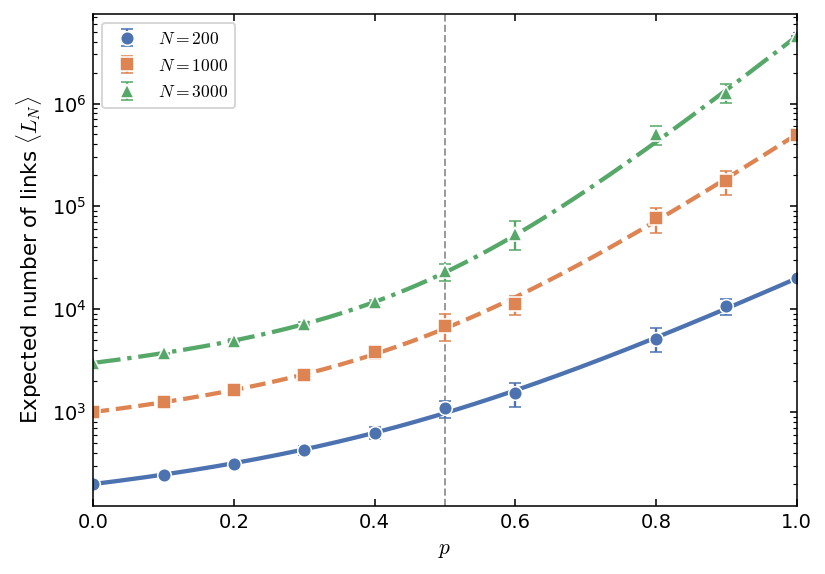

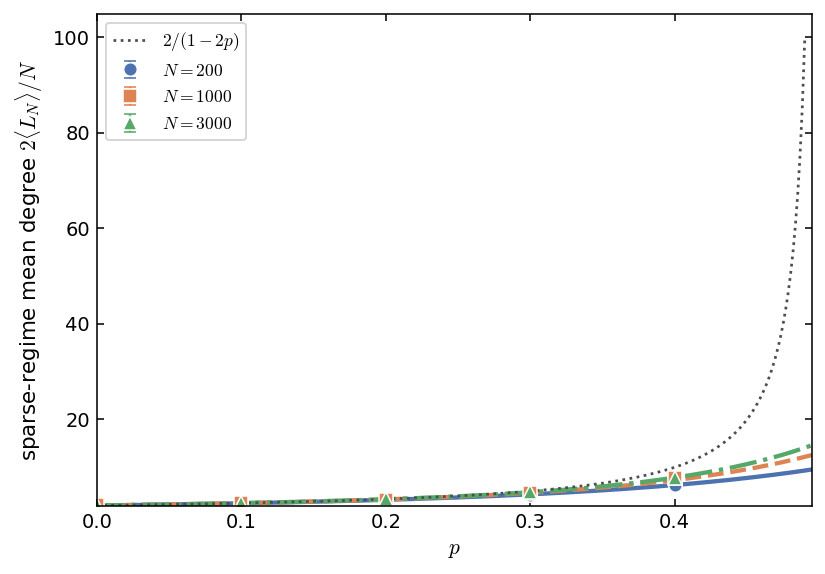

In [58]:
def harmonic_number(n):
    n = np.asarray(n, dtype=float)
    return digamma(n + 1.0) + EULER_GAMMA


def L_exact(N, p):
    N_arr = np.asarray(N, dtype=float)
    p_arr = np.asarray(p, dtype=float)

    if p_arr.ndim == 0:
        if np.isclose(float(p_arr), 0.5):
            return N_arr * (harmonic_number(N_arr) - 1.0)
        log_ratio = gammaln(N_arr + 2.0 * p_arr) - gammaln(N_arr) - gammaln(1.0 + 2.0 * p_arr)
        return (np.exp(log_ratio) - N_arr) / (2.0 * p_arr - 1.0)

    out = np.empty_like(p_arr, dtype=float)
    mask = np.isclose(p_arr, 0.5)
    out[mask] = N_arr * (harmonic_number(N_arr) - 1.0)
    pp = p_arr[~mask]
    log_ratio = gammaln(N_arr + 2.0 * pp) - gammaln(N_arr) - gammaln(1.0 + 2.0 * pp)
    out[~mask] = (np.exp(log_ratio) - N_arr) / (2.0 * pp - 1.0)
    return out


def simulate_edge_curve(N, p_values, n_real, model="aon", seed0=BASE_SEED):
    p_values = tuple(float(p) for p in p_values)
    params = {"N": N, "p_values": p_values, "n_real": n_real, "model": model, "seed0": seed0}

    def _compute():
        gen = generator(model)
        means, cis, cvs = [], [], []
        for j, p in enumerate(p_values):
            vals = np.array([
                gen(N, p, seed=seed0 + 10_000 * j + s).number_of_edges()
                for s in range(n_real)
            ], dtype=float)
            m, ci = mean_ci(vals)
            means.append(m)
            cis.append(ci)
            cvs.append(vals.std(ddof=1) / vals.mean() if vals.mean() > 0 else np.nan)
        return {
            "p": np.array(p_values, dtype=float),
            "mean": np.array(means, dtype=float),
            "ci": np.array(cis, dtype=float),
            "cv": np.array(cvs, dtype=float),
        }

    return cached_compute(f"edge_curve_{model}", params, _compute)


COLORS = ["#4C72B0", "#DD8452", "#55A868"]

# ---------- Expected links ----------
p_sim = np.array(CFG.p_links_sim, dtype=float)
p_line = np.linspace(0.0, 1.0, 400)

fig, ax = plt.subplots(figsize=(6, 4.2))
for i, N in enumerate(CFG.N_links):
    c = COLORS[i]
    marker = MARKERS[i % len(MARKERS)]
    ls = LINESTYLES[i % len(LINESTYLES)]
    sim = simulate_edge_curve(N, p_sim, CFG.n_real_links, model="aon", seed0=BASE_SEED + 1000 * i)
    ax.plot(p_line, L_exact(N, p_line), color=c, lw=2.2, ls=ls)
    ax.errorbar(sim["p"], sim["mean"], yerr=sim["ci"],
                fmt=marker, ms=7, mfc=c, mec="white", mew=0.8,
                color=c, capsize=3, lw=1.2, label=rf"$N={N}$")
ax.axvline(0.5, color="0.6", ls="--", lw=1.0, zorder=0)
ax.set_xlabel(r"$p$")
ax.set_yscale("log")
ax.set_ylabel(r"Expected number of links $\langle L_N\rangle$")
ax.set_xlim(0.0, 1.0)
ax.legend(frameon=True, fancybox=True, shadow=False, edgecolor="0.8", loc="upper left")
fig.tight_layout()
plt.show()

# ---------- Sparse-regime mean degree ----------
p_zoom = np.linspace(0.0, 0.495, 300)

fig, ax = plt.subplots(figsize=(6, 4.2))
for i, N in enumerate(CFG.N_links):
    c = COLORS[i]
    marker = MARKERS[i % len(MARKERS)]
    ls = LINESTYLES[i % len(LINESTYLES)]
    sim = simulate_edge_curve(N, p_sim, CFG.n_real_links, model="aon", seed0=BASE_SEED + 1000 * i)
    ax.plot(p_zoom, 2.0 * L_exact(N, p_zoom) / N, color=c, lw=2.2, ls=ls)
    mask = sim["p"] < 0.495
    ax.errorbar(sim["p"][mask], 2.0 * sim["mean"][mask] / N,
                yerr=2.0 * sim["ci"][mask] / N,
                fmt=marker, ms=7, mfc=c, mec="white", mew=0.8,
                color=c, capsize=3, lw=1.2, label=rf"$N={N}$")
p_ref = np.linspace(0.0, 0.49, 300)
ax.plot(p_ref, 2.0 / (1.0 - 2.0 * p_ref), color="0.3", lw=1.4, ls=":", label=r"$2/(1-2p)$")
ax.axvline(0.5, color="0.6", ls="--", lw=1.0, zorder=0)
ax.set_xlabel(r"$p$")
ax.set_xlim(0.0, 0.495)
ax.set_ylim(1.8, None)
ax.set_ylabel(r"sparse-regime mean degree $2\langle L_N\rangle/N$")
ax.legend(frameon=True, fancybox=True, shadow=False, edgecolor="0.8", loc="upper left")
fig.tight_layout()
plt.show()



## 3. Fluctuations and self-averaging (paper Sec. II B)

Although $\mathbb{E}[\Delta L \mid G_N, i]$ is identical for the two models,
the conditional variance differs.  If the target has degree $k_i$,

$$
\mathrm{Var}_{\mathrm{AoN}}(\Delta L \mid G_N, i) = p(1-p)\, k_i^2, \qquad (5)
$$

whereas the independent-copying analogue is $p(1-p)\, k_i$; the extra
factor of $k_i$ encodes the within-step correlation.  By the law of total
variance, with $Q_N := \sum_i k_i^2$,

$$
\mathrm{Var}_{\mathrm{AoN}}(\Delta L \mid G_N)
= \frac{p\, Q_N}{N} - \frac{4p^2\, L_N^2}{N^2}. \qquad (6)
$$

Squaring $L_{N+1} = L_N + \Delta L$ and taking expectations gives, with
$V(N) := \mathrm{Var}(L_N)$ and $Q(N) := \langle Q_N\rangle$,

$$
V(N+1) = \left(1 + \frac{4p}{N}\right) V(N)
         + \frac{p\, Q(N)}{N} - \frac{4p^{2}}{N^{2}} L(N)^{2}. \qquad (7)
$$

Dominant-balance analysis yields

$$
V(N) \sim
\begin{cases}
C_1(p)\, N, & p < 1/4,\\[2pt]
C_2\, N \ln N, & p = 1/4,\\[2pt]
C_3(p)\, N^{4p}, & p > 1/4.
\end{cases} \qquad (8)
$$

Non-self-averaging sets in for $p > 1/2$: the relative fluctuation
$\sqrt{V(N)}/L(N)$ remains $\mathcal{O}(1)$ as $N \to \infty$.

The two panels below
(i) compare $\mathrm{CV}(L_N) = \sigma(L_N)/\mathbb{E}[L_N]$ for the AoN
and independent-copying models across $N$, and
(ii) show the full $L_N$ distribution at a representative $(N,p)$ where the
means coincide but the spreads differ.

**Figures produced below** *(supplementary)*
- Coefficient of variation $\mathrm{CV}(L_N)$ vs $N$ for the all-or-none
  and independent-copying models.
- Full distribution of $L_N$ at a representative $(N, p)$, illustrating
  that the two models share the same mean but differ in spread.


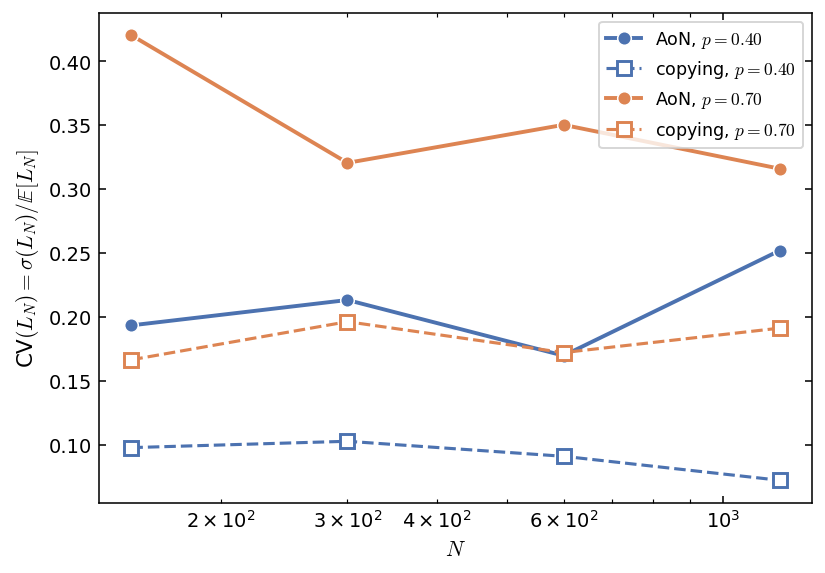

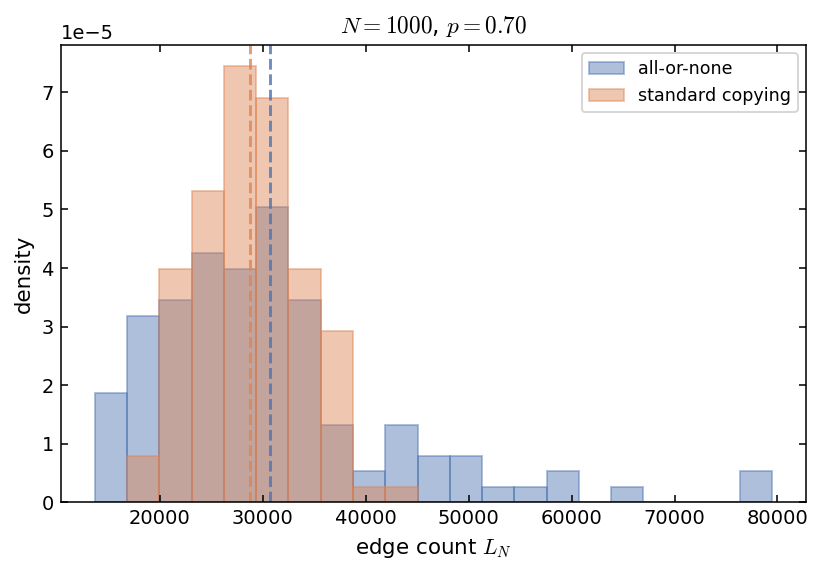

In [59]:
def fluctuation_cv_vs_N(N_values, p_values, n_real, model="aon", seed0=BASE_SEED):
    N_values = tuple(int(N) for N in N_values)
    p_values = tuple(float(p) for p in p_values)
    params = {"N_values": N_values, "p_values": p_values, "n_real": n_real, "model": model, "seed0": seed0}

    def _compute():
        means = np.zeros((len(p_values), len(N_values)))
        cvs = np.zeros_like(means)
        for a, p in enumerate(p_values):
            gen = generator(model)
            for b, N in enumerate(N_values):
                vals = np.array([
                    gen(N, p, seed=seed0 + 10_000 * a + 200 * b + s).number_of_edges()
                    for s in range(n_real)
                ], dtype=float)
                means[a, b] = vals.mean()
                cvs[a, b] = vals.std(ddof=1) / vals.mean()
        return {"N": np.array(N_values), "p": np.array(p_values), "mean": means, "cv": cvs}

    return cached_compute(f"cv_edges_{model}", params, _compute)


def edge_histogram(N, p, n_real, model="aon", seed0=BASE_SEED):
    params = {"N": N, "p": p, "n_real": n_real, "model": model, "seed0": seed0}

    def _compute():
        gen = generator(model)
        vals = np.array([
            gen(N, p, seed=seed0 + s).number_of_edges()
            for s in range(n_real)
        ], dtype=float)
        return {"vals": vals}

    return cached_compute(f"edge_hist_{model}", params, _compute)


fluc_aon = fluctuation_cv_vs_N(CFG.N_fluc, CFG.p_fluc, CFG.n_real_fluc, model="aon", seed0=BASE_SEED + 60_000)
fluc_cop = fluctuation_cv_vs_N(CFG.N_fluc, CFG.p_fluc, CFG.n_real_fluc, model="copy", seed0=BASE_SEED + 70_000)

# --- CV vs N ---
fig, ax = plt.subplots(figsize=(6, 4.2))
cv_colors = ["#4C72B0", "#DD8452"]
for i, p in enumerate(fluc_aon["p"]):
    c = cv_colors[i]
    ax.plot(fluc_aon["N"], fluc_aon["cv"][i], "o-", color=c, mfc=c, mec="white", mew=0.8,
            ms=7, lw=2.0, label=rf"AoN, $p={p:.2f}$")
    ax.plot(fluc_cop["N"], fluc_cop["cv"][i], "s--", color=c, mfc="white", mec=c, mew=1.5,
            ms=7, lw=1.6, label=rf"copying, $p={p:.2f}$")
ax.set_xscale("log")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"CV$(L_N)=\sigma(L_N)/\mathbb{E}[L_N]$")
ax.legend(frameon=True, fancybox=True, edgecolor="0.8", fontsize=9)
fig.tight_layout()
plt.show()

# --- Edge count histogram (filled) ---
hist_aon = edge_histogram(CFG.N_hist, CFG.p_hist, CFG.n_hist, model="aon", seed0=BASE_SEED + 80_000)["vals"]
hist_cop = edge_histogram(CFG.N_hist, CFG.p_hist, CFG.n_hist, model="copy", seed0=BASE_SEED + 90_000)["vals"]

fig, ax = plt.subplots(figsize=(6, 4.2))
bins = np.linspace(min(hist_aon.min(), hist_cop.min()), max(hist_aon.max(), hist_cop.max()), 22)
ax.hist(hist_aon, bins=bins, density=True, alpha=0.45, color="#4C72B0", edgecolor="#4C72B0", lw=1.2, label="all-or-none")
ax.hist(hist_cop, bins=bins, density=True, alpha=0.45, color="#DD8452", edgecolor="#DD8452", lw=1.2, label="standard copying")
ax.axvline(hist_aon.mean(), color="#4C72B0", lw=1.5, ls="--", alpha=0.8)
ax.axvline(hist_cop.mean(), color="#DD8452", lw=1.5, ls="--", alpha=0.8)
ax.set_xlabel(r"edge count $L_N$")
ax.set_ylabel("density")
ax.set_title(rf"$N={CFG.N_hist}$, $p={CFG.p_hist:.2f}$", fontsize=12)
ax.legend(frameon=True, fancybox=True, edgecolor="0.8")
fig.tight_layout()
plt.show()



## 4. Degree distribution (paper Sec. III, Fig. 3)

Let $n_k = N_k/N$ be the stationary degree fraction.  Balancing promotion,
departure, and injection in one growth step yields

$$
(2 + pk)\, n_k = (1 + pk)\, n_{k-1},
\qquad
n_1 = \frac{1-p}{2+p},
$$

valid in the sparse regime $p < 1/2$.  Iterating,

$$
n_k = n_1\,
\frac{\Gamma(k+1+1/p)\,\Gamma(2+2/p)}{\Gamma(2+1/p)\,\Gamma(k+1+2/p)}. \qquad (10)
$$

The large-$k$ asymptotic is the power law

$$
n_k \sim C(p)\, k^{-1/p},
\qquad
\gamma_{\mathrm{AoN}} = \frac{1}{p},
$$

corresponding to the CCDF $\Pr(K \ge k) \sim k^{\,1-1/p}$.
This tail is **heavier** than that of the independent-copying model,
because the correlated birth rule concentrates probability on the
extremes (degree $1$ or $1+k_{\mathrm{target}}$) rather than spreading
the newcomer's degree through a binomial kernel.

**Figure produced below**
- Degree CCDF $\Pr(K \ge k)$ for several $p$ — **paper Fig. 3**


  p=0.1, N=1000000, runs=10...


    total=10000000, max_deg=64
  p=0.2, N=1000000, runs=10...
    total=10000000, max_deg=154
  p=0.4, N=1000000, runs=10...
    total=10000000, max_deg=1355


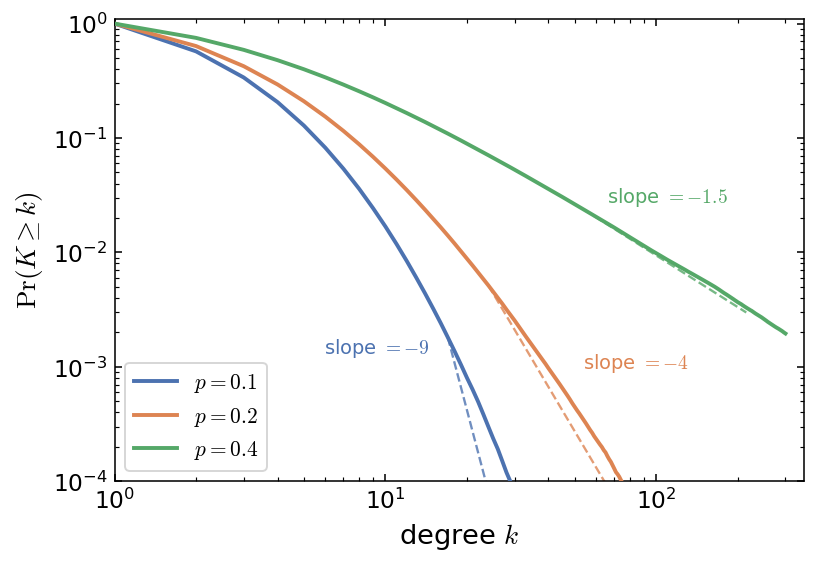

In [60]:
from matplotlib.lines import Line2D

def grow_aon_fast(N, p, seed=None):
    rng = np.random.default_rng(seed)
    adj = [[] for _ in range(N)]
    for v in range(1, N):
        t = int(rng.integers(0, v))
        adj[v].append(t); adj[t].append(v)
        if rng.random() < p:
            for u in list(adj[t]):
                if u != v:
                    adj[v].append(u); adj[u].append(v)
    return np.array([len(adj[i]) for i in range(N)])

def stationary_nk(p, kmax=800):
    nk = np.zeros(kmax+1)
    nk[1] = (1-p)/(2+p)
    for k in range(2, kmax+1):
        nk[k] = (1+p*k)/(2+p*k) * nk[k-1]
    return nk

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'legend.fontsize': 11,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True, 'mathtext.fontset': 'cm',
    'font.weight': 'medium', 'axes.labelweight': 'medium',
})

N_ccdf = 1000000; n_runs_ccdf = CFG.n_real_ccdf
p_values_ccdf = [0.1, 0.2, 0.4]
colors_ccdf = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(6, 4.2))

def _ccdf_all_degs(N, p, n_runs, seed_base):
    def _go():
        arr = np.concatenate([
            grow_aon_fast(N, p, seed=seed_base + s + int(p * 1000) * 100)
            for s in range(n_runs)
        ])
        return {"degs": arr}
    params = {"N": int(N), "p": float(p), "n_runs": int(n_runs), "seed_base": int(seed_base)}
    return cached_compute("ccdf_all_degs", params, _go)["degs"]

sim_data_ccdf = {}
for pi, p in enumerate(p_values_ccdf):
    print(f"  p={p}, N={N_ccdf}, runs={n_runs_ccdf}...", flush=True)
    sim_data_ccdf[p] = _ccdf_all_degs(N_ccdf, p, n_runs_ccdf, seed_base=300)
    print(f"    total={len(sim_data_ccdf[p])}, max_deg={sim_data_ccdf[p].max()}")

for pi, p in enumerate(p_values_ccdf):
    all_degs = sim_data_ccdf[p]
    sorted_d = np.sort(all_degs)
    ccdf_y = 1.0 - np.arange(len(sorted_d)) / len(sorted_d)
    unique_k = np.unique(sorted_d)
    ccdf_at_k = np.array([ccdf_y[np.searchsorted(sorted_d, k)] for k in unique_k])
    counts_above = np.array([np.sum(all_degs >= k) for k in unique_k])
    reliable = counts_above >= 30
    k_plot = unique_k[reliable]
    ccdf_plot = ccdf_at_k[reliable]
    cut = k_plot <= 300
    k_plot = k_plot[cut]; ccdf_plot = ccdf_plot[cut]

    ax.loglog(k_plot, ccdf_plot, '-', color=colors_ccdf[pi], lw=2.0, zorder=3)

    slope = -(1.0/p - 1)
    if p == 0.1:
        idx_a = np.argmin(np.abs(ccdf_plot - 2e-3))
    elif p == 0.2:
        idx_a = np.argmin(np.abs(ccdf_plot - 5e-3))
    else:
        lk = np.log10(k_plot)
        k_a_log = lk.min() + 0.70*(lk.max()-lk.min())
        idx_a = np.argmin(np.abs(np.log10(k_plot) - k_a_log))

    k_a, ccdf_a = k_plot[idx_a], ccdf_plot[idx_a]
    k_sl = np.logspace(np.log10(k_a), np.log10(k_a)+0.6, 30)
    ccdf_sl = ccdf_a * (k_sl/k_a)**slope
    vis = (ccdf_sl > 8e-5) & (ccdf_sl < 1.1) & (k_sl <= 400)
    if vis.any():
        ax.loglog(k_sl[vis], ccdf_sl[vis], '--', color=colors_ccdf[pi],
                  lw=1.2, alpha=0.8, zorder=2)

    k_vis = k_sl[vis]; c_vis = ccdf_sl[vis]
    slope_val = 1.0/p - 1
    label = rf'slope $= -{int(slope_val)}$' if slope_val==int(slope_val) else rf'slope $= -{slope_val:.1f}$'

    if p == 0.1:
        ax.text(k_vis[0]*0.35, c_vis[0]*0.8, label,
                color=colors_ccdf[pi], fontsize=10, fontweight='medium', ha='left', va='center')
    elif p == 0.2:
        idx_txt = int(len(k_vis)*0.6)
        ax.text(k_vis[idx_txt]*1.2, c_vis[idx_txt]*2.0, label,
                color=colors_ccdf[pi], fontsize=10, fontweight='medium', ha='left', va='bottom')
    else:
        mid = len(k_vis)//2
        ax.text(k_vis[mid], c_vis[mid]*3.0, label,
                color=colors_ccdf[pi], fontsize=10, fontweight='medium', ha='center', va='bottom')

ax.set_xlabel(r'degree $k$')
ax.set_ylabel(r'$\Pr(K \geq k)$')
ax.set_xlim(1, 350)
ax.set_ylim(1e-4, 1.1)

handles = [Line2D([0],[0], color=c, lw=2.0, label=rf'$p={p}$')
           for p, c in zip(p_values_ccdf, colors_ccdf)]
ax.legend(handles=handles, frameon=True, fancybox=True, edgecolor='0.8',
          loc='lower left', fontsize=11)

fig.tight_layout()
plt.show()



## 5. Triangles and clique hierarchy (paper Sec. IV)

### Triangles

For a target of degree $k$ with $c$ edges among its neighbours,
$\langle \Delta T \mid k, c\rangle = p(k + c)$, and using
$\sum_i c_i = 3 T_N$ the first-moment recursion is

$$
T(N + 1) = \left(1 + \frac{3p}{N}\right) T(N) + \frac{2p\, L(N)}{N},
\qquad T(1) = 0. \qquad (11)
$$

The asymptotics are

$$
T(N) \sim
\begin{cases}
\dfrac{2p}{(1 - 2p)(1 - 3p)}\, N, & 0 < p < 1/3,\\[6pt]
2 N \ln N, & p = 1/3,\\[6pt]
\dfrac{2}{(3p - 1)\,\Gamma(1 + 3p)}\, N^{3p}, & 1/3 < p \le 1.
\end{cases} \qquad (15)
$$

### Clique hierarchy

Extending to $m$-cliques, define

$$
S_r(N) := \frac{\Gamma(N + rp)}{\Gamma(N)} \sum_{n = 2}^{N} \frac{\Gamma(n)}{\Gamma(n + rp)},
$$

so that $L = S_2$ and $T = 2(S_3 - S_2)$.  Induction on $m$ gives the
exact closed form

$$
K_m(N) = (m - 1) \sum_{q = 0}^{m - 2} (-1)^q \binom{m - 2}{q} S_{m - q}(N), \qquad (18)
$$

and a hierarchy of clique thresholds $p_m = 1/m$ for $m \ge 2$.

**Figures produced below** *(supplementary)*
- $\langle T_N \rangle$ vs $N$ for several $p$ — numerical check of
  the triangle recursion Eq. (11) across the $p = 1/3$ threshold.
- $\langle K_m(N) \rangle$ vs $N$ at $p = 0.30$ for $m = 2, 3, 4$ —
  illustrates the clique hierarchy of Eq. (18).


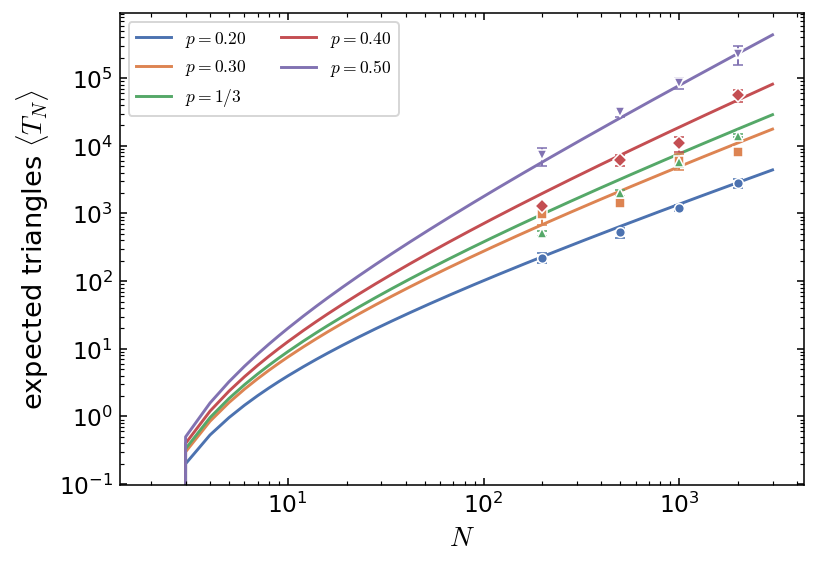

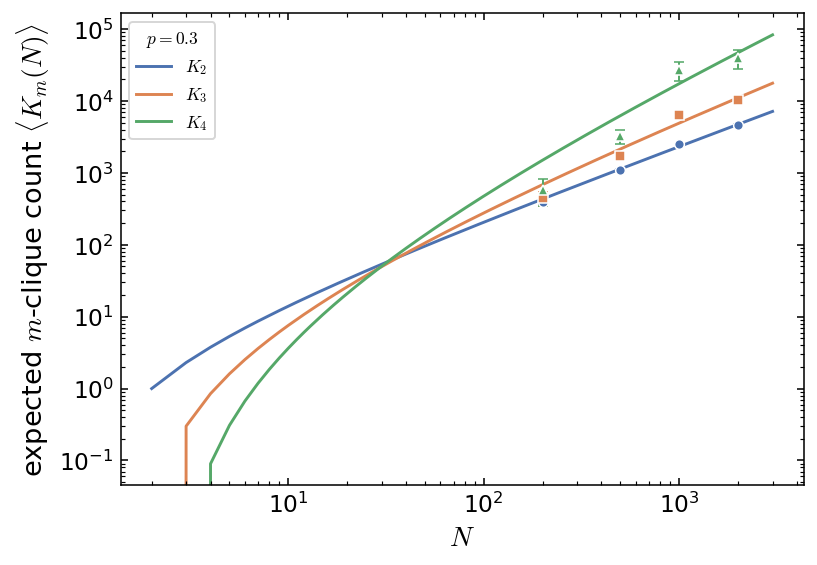

In [61]:
def grow_aon_sets(N, p, seed=None):
    rng = np.random.default_rng(seed)
    adj = [set() for _ in range(N)]
    for v in range(1, N):
        t = int(rng.integers(0, v))
        adj[v].add(t); adj[t].add(v)
        if rng.random() < p:
            for u in list(adj[t]):
                if u != v:
                    adj[v].add(u); adj[u].add(v)
    return adj

def LTQ_recursions_aon(N_max, p):
    """Exact first-moment recursions for L_N, T_N, Q_N (Eqs. 2 and 11)."""
    L = np.zeros(N_max + 1)
    T = np.zeros(N_max + 1)
    Q = np.zeros(N_max + 1)
    for n in range(1, N_max):
        L[n + 1] = (1.0 + 2.0 * p / n) * L[n] + 1.0
        T[n + 1] = (1.0 + 3.0 * p / n) * T[n] + 2.0 * p * L[n] / n
        Q[n + 1] = (1.0 + 3.0 * p / n) * Q[n] + 2.0 + (4.0 + 6.0 * p) * L[n] / n
    return L, T, Q

def Km_recursion(N_max, p, m_max):
    """K_m(N) for m = 2..m_max via the first-moment recursion (Eq. 16)."""
    K = np.zeros((m_max + 1, N_max + 1))
    # K_2 = L via Eq. (2)
    for n in range(1, N_max):
        K[2, n + 1] = (1.0 + 2.0 * p / n) * K[2, n] + 1.0
    # K_m for m >= 3 via (1 + m p / N) K_m(N) + (m - 1) p K_{m-1}(N) / N
    for m in range(3, m_max + 1):
        for n in range(max(m - 1, 1), N_max):
            K[m, n + 1] = (1.0 + m * p / n) * K[m, n] + (m - 1) * p * K[m - 1, n] / n
    return K

def count_triangles_from_adj(adj):
    """Count triangles via edge iteration (each triangle counted 3 times)."""
    cnt = 0
    for u in range(len(adj)):
        for v in adj[u]:
            if v > u:
                cnt += len(adj[u] & adj[v])
    return cnt // 3

def count_k4_from_adj(adj):
    """Enumerate 4-cliques with a < b < c < d."""
    N = len(adj)
    cnt = 0
    for a in range(N):
        na = adj[a]
        for b in na:
            if b <= a:
                continue
            common_ab = na & adj[b]
            for c in common_ab:
                if c <= b:
                    continue
                for d in common_ab & adj[c]:
                    if d > c:
                        cnt += 1
    return cnt

N_tri_sim    = [200, 500, 1000, 2000]
p_tri_values = [0.20, 0.30, 1.0 / 3, 0.40, 0.50]
n_real_tri_sup = 5
N_theory_tri = 3000

theory_T = {}
for p in p_tri_values:
    _, T_arr, _ = LTQ_recursions_aon(N_theory_tri, p)
    theory_T[p] = T_arr

def _triangle_curves(N_sim, p_values, n_real, seed_base):
    def _go():
        mean = np.zeros((len(p_values), len(N_sim)))
        sem  = np.zeros_like(mean)
        for i, p in enumerate(p_values):
            for j, N in enumerate(N_sim):
                vals = []
                for r in range(n_real):
                    seed = seed_base + 10_000 * int(round(p * 100)) + N + r
                    adj = grow_aon_sets(N, p, seed=seed)
                    vals.append(count_triangles_from_adj(adj))
                mean[i, j] = float(np.mean(vals))
                sem[i, j]  = float(np.std(vals) / np.sqrt(n_real))
        return {"mean": mean, "sem": sem}
    params = {"N_sim": tuple(N_sim), "p_values": tuple(float(p) for p in p_values),
              "n_real": int(n_real), "seed_base": int(seed_base)}
    return cached_compute("tri_curves_aon", params, _go)

_tri = _triangle_curves(N_tri_sim, p_tri_values, n_real_tri_sup,
                        seed_base=BASE_SEED + 200_000)
sim_T_mean = {p: list(_tri["mean"][i]) for i, p in enumerate(p_tri_values)}
sim_T_sem  = {p: list(_tri["sem"][i])  for i, p in enumerate(p_tri_values)}

fig, ax = plt.subplots(figsize=(6, 4.2))
tri_colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
tri_markers = ["o", "s", "^", "D", "v"]
N_plot_tri  = np.arange(2, N_theory_tri + 1)

for i, p in enumerate(p_tri_values):
    c = tri_colors[i]
    lab = r"$p = 1/3$" if abs(p - 1/3) < 1e-9 else rf"$p = {p:.2f}$"
    ax.plot(N_plot_tri, theory_T[p][2:], "-", color=c, lw=1.5, zorder=1, label=lab)
    ax.errorbar(N_tri_sim, sim_T_mean[p], yerr=sim_T_sem[p],
                fmt=tri_markers[i], ms=5, mfc=c, mec="white", mew=0.8,
                color=c, lw=0, capsize=2.5, elinewidth=1.0, zorder=3)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"expected triangles $\langle T_N \rangle$")
ax.legend(frameon=True, fancybox=True, edgecolor="0.8",
          loc="upper left", fontsize=9, ncol=2)
fig.tight_layout()
plt.show()

#   reached), K_4 diverges (0.30 > 1/4).
p_hier = 0.30
N_hier_sim = [200, 500, 1000, 2000]
m_max_hier = 4
n_real_hier_sup = 5
N_theory_hier = 3000

K_theory = Km_recursion(N_theory_hier, p_hier, m_max_hier)

def _clique_curves(N_sim, p, m_max, n_real, seed_base):
    def _go():
        mean = np.zeros((m_max + 1, len(N_sim)))
        sem  = np.zeros_like(mean)
        for j, N in enumerate(N_sim):
            per_m = {m: [] for m in range(2, m_max + 1)}
            for r in range(n_real):
                seed = seed_base + N + r
                adj = grow_aon_sets(N, p, seed=seed)
                per_m[2].append(sum(len(s) for s in adj) // 2)
                per_m[3].append(count_triangles_from_adj(adj))
                if m_max >= 4:
                    per_m[4].append(count_k4_from_adj(adj))
            for m in range(2, m_max + 1):
                mean[m, j] = float(np.mean(per_m[m]))
                sem[m, j]  = float(np.std(per_m[m]) / np.sqrt(n_real))
        return {"mean": mean, "sem": sem}
    params = {"N_sim": tuple(N_sim), "p": float(p), "m_max": int(m_max),
              "n_real": int(n_real), "seed_base": int(seed_base)}
    return cached_compute("clique_curves_aon", params, _go)

_km = _clique_curves(N_hier_sim, p_hier, m_max_hier, n_real_hier_sup,
                     seed_base=BASE_SEED + 300_000)
sim_km_mean = {m: list(_km["mean"][m]) for m in range(2, m_max_hier + 1)}
sim_km_sem  = {m: list(_km["sem"][m])  for m in range(2, m_max_hier + 1)}

fig, ax = plt.subplots(figsize=(6, 4.2))
hier_colors  = ["#4C72B0", "#DD8452", "#55A868"]
hier_markers = ["o", "s", "^"]
N_plot_hier = np.arange(2, N_theory_hier + 1)

for idx, m in enumerate([2, 3, 4]):
    c = hier_colors[idx]
    ax.plot(N_plot_hier, K_theory[m, 2:], "-", color=c, lw=1.5, zorder=1,
            label=rf"$K_{m}$")
    mean_arr = np.asarray(sim_km_mean[m], dtype=float)
    sem_arr  = np.asarray(sim_km_sem[m], dtype=float)
    mask = mean_arr > 0
    if mask.any():
        ax.errorbar(np.asarray(N_hier_sim)[mask], mean_arr[mask], yerr=sem_arr[mask],
                    fmt=hier_markers[idx], ms=5, mfc=c, mec="white", mew=0.8,
                    color=c, lw=0, capsize=2.5, elinewidth=1.0, zorder=3)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$N$")
ax.set_ylabel(r"expected $m$-clique count $\langle K_m(N) \rangle$")
ax.legend(frameon=True, fancybox=True, edgecolor="0.8",
          loc="upper left", fontsize=9,
          title=rf"$p = {p_hier}$", title_fontsize=9)
fig.tight_layout()
plt.show()



## 6. Clustering and average shortest-path distance (paper Sec. V)

### Global transitivity and local clustering

Let $W_N$ be the wedge count.  Its first moment satisfies

$$
W(N + 1) = \left(1 + \frac{3p}{N}\right) W(N) + \frac{2(1 + 2p)\, L(N)}{N}, \qquad (20)
$$

which has the same homogeneous coefficient as (11).  The difference
$W(N) - \tfrac{1 + 2p}{p} T(N)$ solves the homogeneous recursion and
vanishes at $N = 1$, yielding the $N$-independent ratio

$$
\frac{3 \langle T_N \rangle}{\langle W_N \rangle} = \frac{3p}{1 + 2p}. \qquad (21)
$$

Simulations of the transitivity $\tau_N$ and the local clustering
$\bar c_N$ stay $\mathcal{O}(1)$ throughout $0 < p < 1$, in contrast to
an Erdős-Rényi graph with the same mean degree.

### Average average shortest-path distance

Let $\Sigma_N = \sum_{i < j} d_N(i, j)$ and
$\ell_N = 2 \Sigma_N / [N(N - 1)]$.  Because a newborn $x$ inherits at
most its target's neighbourhood, any old-old path through $x$ can be
rerouted through the target $v$, so old-old distances are unchanged.
Conditioning on the copy indicator and using
$\sum_v D_N(v) = 2 \Sigma_N$ gives

$$
\mathbb{E}[\Sigma_{N + 1} \mid G_N]
= \left(1 + \frac{2}{N}\right) \Sigma_N + (1 - p) N + p. \qquad (22)
$$

Solving by the integrating factor yields the closed form

$$
\mathbb{E}[\ell_N]
= 2 \, \frac{N + 1}{N - 1}
\left[(1 - p) H_N + \frac{2 - 3p}{N + 1} + \frac{5p}{2} - 2\right], \qquad (23)
$$

whose leading asymptotic is

$$
\mathbb{E}[\ell_N] = 2(1 - p) \ln N + 2(1 - p) \gamma + 5p - 4
+ \mathcal{O}\!\left(\tfrac{\ln N}{N}\right). \qquad (24)
$$

Combined with the non-vanishing clustering above, this establishes the
**small-world property** for every $p \in (0, 1)$.

**Figures produced below**
- Global transitivity $\tau_N$ and local clustering $\bar c_N$ vs $p$ — **paper Fig. 4**
- $\langle \ell_N \rangle$ vs $N$ for several $p$ — **paper Fig. 5**


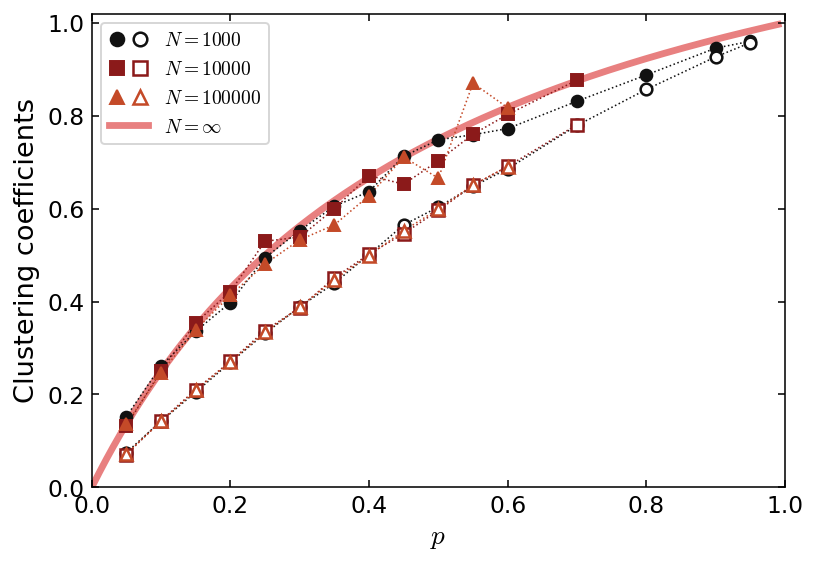

In [62]:
import time
from matplotlib.legend_handler import HandlerTuple

# ── Fast graph builder returning adjacency sets (avoids NetworkX overhead) ──
def clustering_from_adj(adj):
    """Compute transitivity and average local clustering from adjacency sets."""
    N = len(adj)
    total_triangles = 0
    total_triplets = 0
    local_sum = 0.0
    for v in range(N):
        d = len(adj[v])
        if d < 2:
            continue
        triplets_v = d * (d - 1) // 2
        total_triplets += triplets_v
        triangles_v = 0
        nbrs = adj[v]
        for u in nbrs:
            triangles_v += len(nbrs & adj[u])
        triangles_v //= 2
        total_triangles += triangles_v
        local_sum += triangles_v / triplets_v
    transitivity = total_triangles / total_triplets if total_triplets > 0 else 0.0
    avg_clustering = local_sum / N
    return transitivity, avg_clustering

# ── Bhat Fig. 7 style: clustering coefficients vs p, multiple N ──
p_clus = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
                   0.50, 0.55, 0.60, 0.70, 0.80, 0.90, 0.95])

# smaller p-range for larger N (as in the original paper)
# realisations per N are taken from CFG.n_real_cluster = (n1000, n10000, n100000)
_nc = CFG.n_real_cluster
configs = {
    1000:   (p_clus,                  _nc[0]),   # full range
    10000:  (p_clus[p_clus <= 0.70],  _nc[1]),   # up to 0.70
    100000: (p_clus[p_clus <= 0.60],  _nc[2]),   # up to 0.60
}

def _clustering_for_N(N, p_vals, n_real, seed_shift):
    def _go():
        tau_arr = np.zeros(len(p_vals))
        cc_arr  = np.zeros(len(p_vals))
        for j, p in enumerate(p_vals):
            t0 = time.time()
            tau_runs, cc_runs = [], []
            for r in range(n_real):
                seed = BASE_SEED + 10_000 * j + N + r * seed_shift
                adj = grow_aon_sets(N, p, seed=seed)
                tau, cc = clustering_from_adj(adj)
                tau_runs.append(tau)
                cc_runs.append(cc)
            tau_arr[j] = float(np.mean(tau_runs))
            cc_arr[j]  = float(np.mean(cc_runs))
            print(f"  N={N:>6d}, p={p:.2f}  tau={tau_arr[j]:.4f}  cc={cc_arr[j]:.4f}  x{n_real}  ({time.time()-t0:.1f}s)", flush=True)
        return {"p": np.asarray(p_vals, dtype=float), "tau": tau_arr, "cc": cc_arr}
    params = {"N": int(N), "p_vals": tuple(float(p) for p in p_vals),
              "n_real": int(n_real), "seed_shift": int(seed_shift)}
    return cached_compute("clustering_curve_aon", params, _go)

results = {}
for N, (p_vals, n_real) in configs.items():
    r_dict = _clustering_for_N(N, p_vals, n_real, seed_shift=777)
    results[N] = {"p": np.asarray(p_vals), "tau": r_dict["tau"], "cc": r_dict["cc"]}

# Theory: tau(N->inf) = 3p/(1+2p)
p_theory = np.linspace(0.001, 0.99, 300)
tau_theory = 3.0 * p_theory / (1.0 + 2.0 * p_theory)

# ── Plot ──
fig, ax = plt.subplots(figsize=(6, 4.2))

colors = ["#111111", "#8B1A1A", "#C44A28"]
markers = ["o", "s", "^"]

for idx, N in enumerate([1000, 10000, 100000]):
    c = colors[idx]
    r = results[N]
    p_v = r["p"]
    # transitivity: filled markers + dotted line
    ax.plot(p_v, r["tau"], ":", color=c, lw=0.8, zorder=2)
    ax.plot(p_v, r["tau"], markers[idx], ms=6,
            mfc=c, mec=c, lw=0, zorder=3)
    # local clustering: open markers + dotted line
    ax.plot(p_v, r["cc"], ":", color=c, lw=0.8, zorder=2)
    ax.plot(p_v, r["cc"], markers[idx], ms=6,
            mfc="white", mec=c, mew=1.3, lw=0, zorder=3)

# N=inf theory
ax.plot(p_theory, tau_theory, "-", color="#E88080", lw=3.5, zorder=1)

ax.set_xlabel(r"$p$")
ax.set_ylabel(r"Clustering coefficients")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

# Legend: each N row shows filled (tau) + open (cc) side by side
handles_paired = []
labels_paired = []
for idx, N in enumerate([1000, 10000, 100000]):
    c = colors[idx]
    h_filled = Line2D([0], [0], marker=markers[idx], color="w",
                       mfc=c, mec=c, ms=7, lw=0)
    h_open = Line2D([0], [0], marker=markers[idx], color="w",
                     mfc="white", mec=c, mew=1.3, ms=7, lw=0)
    handles_paired.append((h_filled, h_open))
    labels_paired.append(rf"$N = {N}$")

h_theory = Line2D([0], [0], color="#E88080", lw=3.5)
handles_paired.append(h_theory)
labels_paired.append(r"$N = \infty$")

ax.legend(handles_paired, labels_paired,
          handler_map={tuple: HandlerTuple(ndivide=None)},
          frameon=True, fancybox=True, edgecolor="0.8",
          loc="upper left", fontsize=10)

fig.tight_layout()
plt.show()


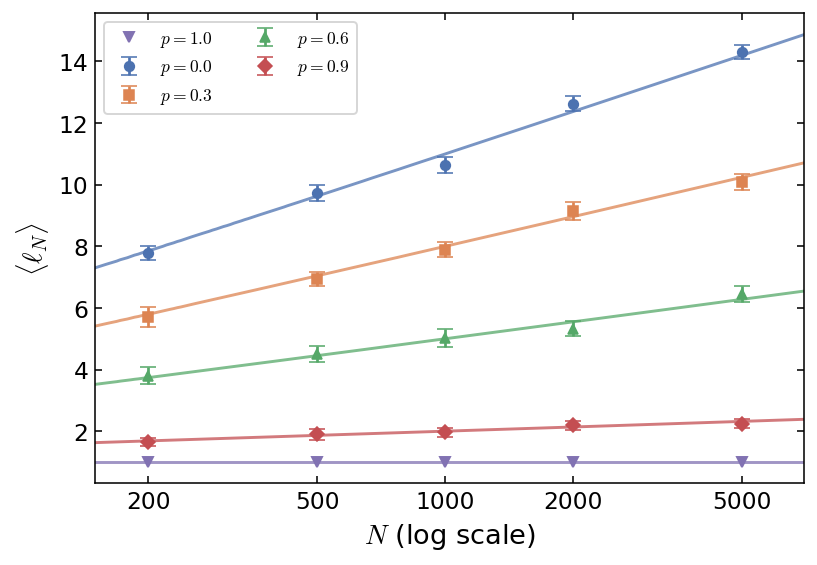

In [63]:
# --- Shortest path length vs N (reproduces paper Fig. 5) ---
from collections import deque
from matplotlib.ticker import ScalarFormatter


def avg_shortest_path_fast(adj, n_sources=None, seed=None):
    """Average shortest path on the largest connected component.
    If n_sources is given, estimate from that many random BFS sources."""
    N = len(adj)
    seen = [False] * N
    best = []
    for start in range(N):
        if seen[start]:
            continue
        comp = []
        q = deque([start])
        seen[start] = True
        while q:
            u = q.popleft()
            comp.append(u)
            for v in adj[u]:
                if not seen[v]:
                    seen[v] = True
                    q.append(v)
        if len(comp) > len(best):
            best = comp
    M = len(best)
    if M < 2:
        return 0.0
    if n_sources is None or n_sources >= M:
        sources = best
    else:
        rng = np.random.default_rng(seed)
        sources = [best[i] for i in rng.choice(M, size=n_sources, replace=False)]
    total = 0
    pairs = 0
    for s in sources:
        dist = [-1] * N
        dist[s] = 0
        q = deque([s])
        while q:
            u = q.popleft()
            du = dist[u]
            for v in adj[u]:
                if dist[v] == -1:
                    dist[v] = du + 1
                    q.append(v)
        for w in best:
            if dist[w] > 0:
                total += dist[w]
                pairs += 1
    return total / pairs if pairs > 0 else 0.0


def ell_theory(N, p):
    """Closed form for E[l_N], Eq. (23) in the paper."""
    if N < 2:
        return 0.0
    H_N = float(np.sum(1.0 / np.arange(1, N + 1)))
    bracket = (1.0 - p) * H_N + (2.0 - 3.0 * p) / (N + 1) + 5.0 * p / 2.0 - 2.0
    return 2.0 * (N + 1) / (N - 1) * bracket


def _n_sources_for(N):
    if N <= 500:  return None    # exact
    if N <= 2000: return 150
    return 80                     # N >= 5000


def simulate_paths(N_values, p_values, n_real, seed0=BASE_SEED):
    means = np.zeros((len(p_values), len(N_values)))
    cis   = np.zeros_like(means)
    for a, p in enumerate(p_values):
        for b, N in enumerate(N_values):
            if p >= 1.0:
                means[a, b] = 1.0
                cis[a, b] = 0.0
                continue
            ells = []
            k = _n_sources_for(N)
            for r in range(n_real):
                seed = seed0 + 10_000 * a + 200 * b + r
                adj = grow_aon_sets(N, p, seed=seed)
                ells.append(avg_shortest_path_fast(adj, n_sources=k, seed=seed + 1))
            m, ci = mean_ci(ells)
            means[a, b] = m
            cis[a, b]   = ci
    return {"N": np.array(N_values), "p": np.array(p_values),
            "mean": means, "ci": cis}


def _cached_paths(N_values, p_values, n_real, seed0):
    def _go():
        return simulate_paths(N_values, p_values, n_real, seed0=seed0)
    params = {"N_values": tuple(int(N) for N in N_values),
              "p_values": tuple(float(p) for p in p_values),
              "n_real": int(n_real), "seed0": int(seed0),
              "sampler": "sampled_sources_v1"}
    return cached_compute("shortest_path_aon_sampled", params, _go)


N_path_full = list(CFG.N_path)
p_path_full = list(CFG.p_path)
paths = _cached_paths(N_path_full, p_path_full,
                      n_real=CFG.n_real_path, seed0=BASE_SEED + 50_000)

PATH_COLORS  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
PATH_MARKERS = ["o", "s", "^", "D", "v"]

fig, ax = plt.subplots(figsize=(6, 4.2))
N_smooth = np.logspace(np.log10(150), np.log10(7000), 200)

for i, p in enumerate(paths["p"]):
    c = PATH_COLORS[i % len(PATH_COLORS)]
    marker = PATH_MARKERS[i % len(PATH_MARKERS)]
    theory_curve = np.array([ell_theory(int(round(Nx)), p) for Nx in N_smooth])
    ax.plot(N_smooth, theory_curve, "-", color=c, alpha=0.75, lw=1.5, zorder=1)
    if p >= 1.0:
        ax.plot(paths["N"], paths["mean"][i], marker, ms=5, mfc=c, mec=c, lw=0,
                label=rf"$p={p:.1f}$", zorder=3)
    else:
        ax.errorbar(paths["N"], paths["mean"][i], yerr=paths["ci"][i],
                    fmt=marker, ms=5, mfc=c, mec=c, mew=0.8,
                    color=c, lw=0, capsize=4, capthick=1.4, elinewidth=1.4,
                    label=rf"$p={p:.1f}$", zorder=3)

ax.set_xscale("log")
ax.set_xlabel(r"$N$ (log scale)")
ax.set_ylabel(r"$\langle\ell_N\rangle$")
ax.set_xticks(N_path_full)
ax.set_xticks([], minor=True)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xlim(150, 7000)
ax.legend(frameon=True, fancybox=True, edgecolor="0.8",
          loc="upper left", fontsize=9, ncol=2)
fig.tight_layout()
plt.show()



## 7. Degree assortativity (paper Sec. VI, Fig. 6)

We report the Pearson degree-degree correlation coefficient
$r \in [-1, 1]$.  Empirically $r$ is predominantly
positive for $p > 0$: starting from a slightly negative value at
$p = 0$ (random recursive tree), it rises sharply with $p$, reaches a
broad maximum near $p \approx 1/2$, and decreases mildly thereafter.
The error bars broaden for $p > 1/2$, consistent with the loss of
self-averaging established in Sec. 3.

**Figure produced below**
- Degree assortativity $r$ vs $p$ for several $N$ — **paper Fig. 6**


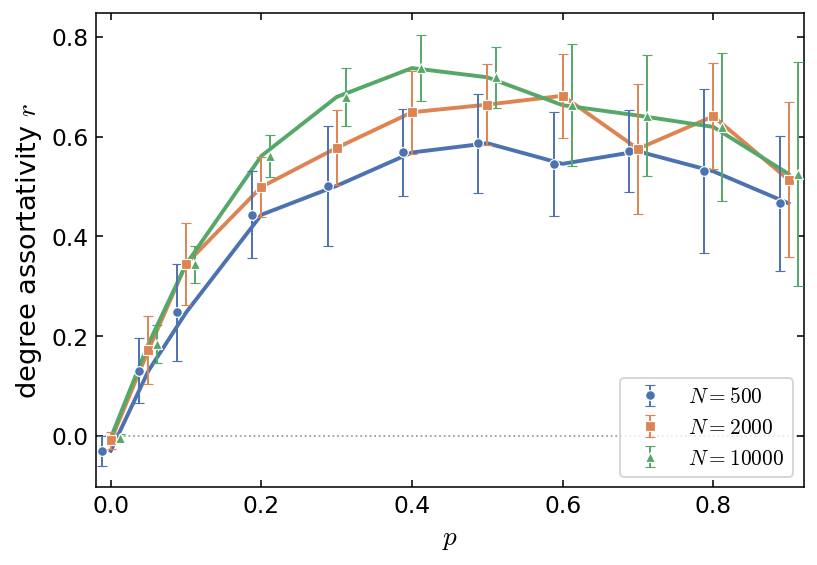

In [64]:
def assortativity_from_adj(adj):
    """Pearson degree assortativity (Newman 2002) from adjacency sets."""
    N = len(adj)
    degs = np.array([len(s) for s in adj], dtype=np.int64)
    M2 = int(degs.sum())
    if M2 == 0:
        return float("nan")
    M = M2 // 2
    S2 = int((degs * degs).sum())
    S3 = int((degs * degs * degs).sum())
    A = 0
    for u in range(N):
        du = int(degs[u])
        for v in adj[u]:
            if v > u:
                A += du * int(degs[v])
    denom = 2 * M * S3 - S2 * S2
    if denom == 0:
        return float("nan")
    return (4 * M * A - S2 * S2) / denom


def simulate_assortativity_fast(Ns, p_values, n_real, seed0=BASE_SEED):
    """Fast AON assortativity across (N, p) with multiple realisations."""
    results = {N: {"mean": np.full(len(p_values), np.nan),
                   "std":  np.full(len(p_values), np.nan)} for N in Ns}
    for N in Ns:
        for j, p in enumerate(p_values):
            rs = []
            for r in range(n_real):
                seed = seed0 + 10_000 * int(p * 100) + N + r
                adj = grow_aon_sets(N, p, seed=seed)
                val = assortativity_from_adj(adj)
                if np.isfinite(val):
                    rs.append(val)
            if rs:
                rs = np.array(rs)
                results[N]["mean"][j] = rs.mean()
                results[N]["std"][j]  = rs.std()
    return results

# --- Assortativity vs p, multiple N (all-or-none) ---
ps_assort = list(CFG.p_assort)
Ns_assort = list(CFG.N_assort)
def _cached_assort(Ns, ps, n_real, seed0):
    def _go():
        r = simulate_assortativity_fast(Ns, ps, n_real, seed0=seed0)
        # simulate_assortativity_fast returns dict-of-N -> {mean, std}; flatten.
        Ns_arr = np.asarray(Ns)
        mean = np.stack([r[N]["mean"] for N in Ns], axis=0)
        std  = np.stack([r[N]["std"]  for N in Ns], axis=0)
        return {"Ns": Ns_arr, "ps": np.asarray(ps), "mean": mean, "std": std}
    params = {"Ns": tuple(int(N) for N in Ns), "ps": tuple(float(p) for p in ps),
              "n_real": int(n_real), "seed0": int(seed0)}
    flat = cached_compute("assortativity_aon", params, _go)
    # Reconstruct the dict-of-N shape the plotting code expects.
    out = {}
    for i, N in enumerate(Ns):
        out[N] = {"mean": flat["mean"][i], "std": flat["std"][i]}
    return out

assort_results = _cached_assort(Ns_assort, ps_assort,
                                n_real=CFG.n_real_assort,
                                seed0=BASE_SEED + 30_000)

fig, ax = plt.subplots(figsize=(6, 4.2))

assort_style = {
    500:   dict(marker="o", color="#4C72B0", label=r"$N=500$"),
    2000:  dict(marker="s", color="#DD8452", label=r"$N=2000$"),
    10000: dict(marker="^", color="#55A868", label=r"$N=10000$"),
}

# r=0 reference line
ax.axhline(0, color="0.6", linestyle=":", linewidth=0.9, zorder=0)

# Small horizontal dodge so overlapping error bars stay readable
ps_arr = np.array(ps_assort)
dodge = {500: -0.012, 2000: 0.0, 10000: +0.012}

for N in Ns_assort:
    mean = assort_results[N]["mean"]
    std  = assort_results[N]["std"]
    c = assort_style[N]["color"]
    # Connecting line at true p (no dodge)
    ax.plot(ps_arr, mean, "-", color=c, lw=2.0, zorder=2)
    # Dodged markers + error bars (std)
    ax.errorbar(ps_arr + dodge[N], mean, yerr=std,
                fmt=assort_style[N]["marker"],
                ms=5, mfc=c, mec="white", mew=0.6,
                color=c, lw=0,
                elinewidth=1.0, capsize=2.5,
                label=assort_style[N]["label"], zorder=3)

ax.set_xlabel(r"$p$")
ax.set_ylabel(r"degree assortativity $r$")
ax.set_xlim(-0.02, 0.92)
ax.set_xticks(np.arange(0.0, 1.0, 0.2))
ax.legend(frameon=True, fancybox=True, edgecolor="0.8", loc="lower right")
fig.tight_layout()
plt.show()



## 8. Phase diagram (paper summary)

Summary of the structural transitions in the all-or-none model.
For each subgraph count ($L$, $T$, $K_4$, …, $K_m$) the scaling switches
from linear in $N$ to the dense power law $N^{mp}$ at the threshold
$p_m = 1/m$.  The densification threshold $p_c = 1/2$ is the $m=2$ case.

**Figure produced below**
- Phase-diagram schematic — corresponds to the summary panel of paper Fig. 1.


C:\Users\Administrator\AppData\Local\Temp\ipykernel_43032\661552564.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.2)


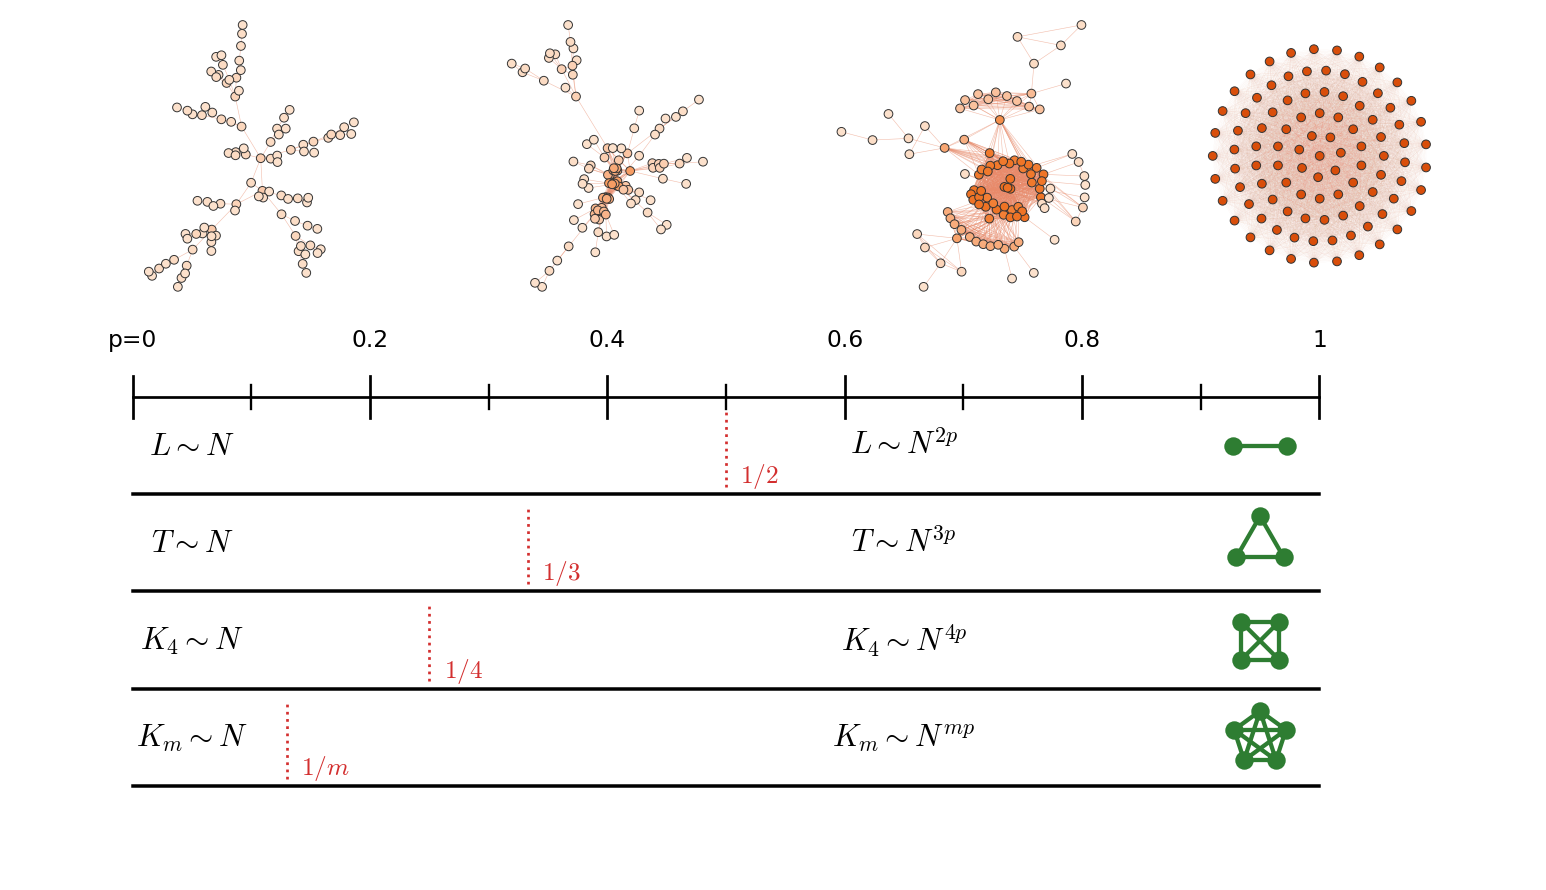

In [65]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

ICON_COLOR = "#2E7D32"
LINE_BLACK = "#000000"
THRESH_RED = "#D32F2F"

fig = plt.figure(figsize=(14.0, 8.0))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 2.0], hspace=0.02)

# ── top: 4 network visualizations (Bhat-style) ──
ax_top = fig.add_subplot(gs[0])
ax_top.set_xlim(-0.10, 1.18)
ax_top.set_ylim(0, 1)
ax_top.axis("off")

N_vis = 100
p_vis = [0.1, 0.4, 0.7, 1.0]
x_centers = list(p_vis)  # exact alignment with p-axis

for p, xc in zip(p_vis, x_centers):
    G = grow_all_or_none(N_vis, p, seed=7)
    # layout per density regime
    if p == 0.0:
        pos = nx.kamada_kawai_layout(G)
    elif p >= 1.0:
        # concentric shells to fill the disk
        nodes = list(G.nodes())
        shells = []
        rem = nodes[:]
        ring_sizes = [1, 7, 14, 21, 28, 29]   # sums to 100
        for size in ring_sizes:
            if not rem: break
            shells.append(rem[:size])
            rem = rem[size:]
        pos = nx.shell_layout(G, nlist=shells)
    elif p >= 0.5:
        # dense: MST skeleton + hub-incident edges, laid out by kamada_kawai
        T = nx.minimum_spanning_tree(G)
        deg_list = sorted(G.nodes(), key=lambda n: -G.degree(n))
        top_hubs = deg_list[:3]
        H = T.copy()
        for h in top_hubs:
            for v in G.neighbors(h):
                H.add_edge(h, v)
        pos = nx.kamada_kawai_layout(H)
    else:
        pos = nx.spring_layout(G, seed=5, k=3.0/np.sqrt(N_vis),
                               iterations=300, scale=1.0)
    xs = np.array([pos[n][0] for n in G.nodes()])
    ys = np.array([pos[n][1] for n in G.nodes()])
    # aspect-preserving normalization, centered at (xc, 0.5)
    sx = xs.max() - xs.min()
    sy = ys.max() - ys.min()
    s = max(sx, sy, 1e-9)
    xs = (xs - (xs.min() + xs.max())/2) / s   # centered in [-0.5, 0.5]
    ys = (ys - (ys.min() + ys.max())/2) / s
    if p >= 1.0:
        panel_w, panel_h = 0.18, 0.75
    else:
        panel_w, panel_h = 0.26, 0.92
    xs = xc + panel_w * xs
    ys = 0.50 + panel_h * ys
    node_list = list(G.nodes())
    deg = np.array([G.degree(n) for n in node_list], dtype=float)

    # unified faint edge style for all graphs
    n_edges = G.number_of_edges()
    if n_edges > 2000:
        edge_alpha, edge_lw = 0.15, 0.08
    else:
        edge_alpha, edge_lw = 0.55, 0.30
    for u, v in G.edges():
        i = node_list.index(u); j = node_list.index(v)
        ax_top.plot([xs[i], xs[j]], [ys[i], ys[j]],
                    "-", color="#E88A6A", lw=edge_lw, alpha=edge_alpha, zorder=1)

    # FIXED absolute-degree color scale (same across all graphs)
    # light orange -> medium orange -> deep orange (no black)
    from matplotlib.colors import LinearSegmentedColormap
    cmap = LinearSegmentedColormap.from_list("orange_ramp",
        ["#FCE4D0", "#F9B48A", "#F58A42", "#EC6A1A", "#D94E0A"])
    # absolute degree bins: clamp at 0..60 (beyond that all deep orange)
    DEG_MAX = 60.0
    dnorm = np.clip(deg / DEG_MAX, 0.0, 1.0)
    colors = cmap(dnorm)
    # all nodes get the same dark outline and uniform size
    ax_top.scatter(xs, ys, s=20, c=colors,
                   edgecolors="#333333", linewidths=0.5, zorder=2)

# ── bottom: phase diagram ──
ax = fig.add_subplot(gs[1])
ax.set_xlim(-0.10, 1.18)
ax.set_ylim(2.2, 6.0)
ax.axis("off")

y_axis = 5.4
ax.plot([0, 1], [y_axis, y_axis], "-", color="black", lw=1.4)
# major ticks with labels
for v in [0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot([v, v], [y_axis - 0.14, y_axis + 0.14], "-", color="black", lw=1.4)
    if v == 0:
        ax.text(v, y_axis + 0.30, "p=0", ha="center", va="bottom", fontsize=12)
    elif v == 1:
        ax.text(v, y_axis + 0.30, "1", ha="center", va="bottom", fontsize=12)
    else:
        ax.text(v, y_axis + 0.30, f"{v}", ha="center", va="bottom", fontsize=12)
# minor ticks without labels
for v in [0.1, 0.3, 0.5, 0.7, 0.9]:
    ax.plot([v, v], [y_axis - 0.08, y_axis + 0.08], "-", color="black", lw=1.2)

line_ys = [4.75, 4.10, 3.45, 2.80]
line_colors = [LINE_BLACK] * 4
icon_ys = [y + 0.32 for y in line_ys]

rows = [
    (1/2,  r"$L \sim N$",    r"$L \sim N^{2p}$",   r"$1/2$"),
    (1/3,  r"$T \sim N$",    r"$T \sim N^{3p}$",   r"$1/3$"),
    (1/4,  r"$K_4 \sim N$",  r"$K_4 \sim N^{4p}$", r"$1/4$"),
    (None, r"$K_m \sim N$",  r"$K_m \sim N^{mp}$", r"$1/m$"),
]

def _shape_pts(kind):
    if kind == "edge":
        return np.array([[-1,0],[1,0]]), [(0,1)]
    if kind == "tri":
        ang = np.array([90, 210, 330]) * np.pi / 180
        return np.stack([np.cos(ang), np.sin(ang)], axis=1), [(0,1),(1,2),(0,2)]
    if kind == "k4":
        return (np.array([[-1,-1],[1,-1],[1,1],[-1,1]]) / np.sqrt(2),
                [(0,1),(1,2),(2,3),(3,0),(0,2),(1,3)])
    if kind == "k5":
        ang = np.arange(5) * 72 * np.pi / 180 + np.pi/2
        return np.stack([np.cos(ang), np.sin(ang)], axis=1), [(i,j) for i in range(5) for j in range(i+1,5)]

def draw_icon_at(ax, cx, cy, kind, radius_pts=14):
    base_pts, edges = _shape_pts(kind)
    x0, y0 = ax.transData.transform((cx, cy))
    r_disp = radius_pts * fig.dpi / 72.0
    disp_pts = base_pts * r_disp + np.array([x0, y0])
    inv = ax.transData.inverted()
    data_pts = np.array([inv.transform(p) for p in disp_pts])
    for i, j in edges:
        ax.plot([data_pts[i,0], data_pts[j,0]], [data_pts[i,1], data_pts[j,1]],
                "-", color=ICON_COLOR, lw=2.2, solid_capstyle="round", zorder=3)
    ax.scatter(data_pts[:,0], data_pts[:,1], s=90, c=ICON_COLOR,
               edgecolors=ICON_COLOR, linewidths=0, zorder=4)

icon_kinds = ["edge", "tri", "k4", "k5"]
ICON_X = 0.95

for k, (row, line_y, icon_y, line_c, kind) in enumerate(
        zip(rows, line_ys, icon_ys, line_colors, icon_kinds)):
    p_c, left_lab, right_lab, th_text = row
    p_thr = p_c if p_c is not None else 0.13

    ax.plot([0.0, 1.0], [line_y, line_y], "-", color=line_c, lw=1.8, zorder=2)
    upper_y = line_ys[k-1] if k > 0 else y_axis
    ax.plot([p_thr, p_thr], [line_y + 0.05, upper_y - 0.10],
            ":", color=THRESH_RED, lw=1.4, zorder=3)
    ax.text(p_thr + 0.012, line_y + 0.12, th_text,
            ha="left", va="center", fontsize=13, color=THRESH_RED,
            bbox=dict(facecolor="white", edgecolor="none", pad=0.6))
    # fixed x: left label at 0.05, right at 0.65
    ax.text(0.05, icon_y, left_lab, ha="center", va="center",
            fontsize=16, color="black")
    ax.text(0.65, icon_y, right_lab, ha="center", va="center",
            fontsize=16, color="black")
    draw_icon_at(ax, ICON_X, icon_y, kind, radius_pts=14)

plt.tight_layout(pad=0.2)
plt.show()


## 9. Spectral radius (bonus)

The conclusion of the paper flags that the non-self-averaging
established in Sec. II B may also show up in the adjacency spectral
radius $\lambda_{\max}$. This section is a first numerical look that
goes beyond the main text.

### Motivation

For an undirected graph, the leading adjacency eigenvalue
$\lambda_1(A)$ governs several linear dynamics on the network:
the epidemic threshold of the SIS model and the synchronisation
threshold of coupled oscillators both scale as $1/\lambda_1$. It is
therefore natural to ask how $\lambda_1$ depends on the copying
probability $p$, and which vertices drive it.

The dynamical-importance score introduced by Restrepo, Ott and Hunt
(Phys. Rev. Lett. 97, 094102, 2006) quantifies the drop of $\lambda_1$
caused by removing vertex $k$. For undirected graphs the score reduces
to $I_k \propto u_k^2$, where $u$ is the (normalised) leading
eigenvector of $A$. We therefore use $u_k^2$ as a principled attack
heuristic and compare it against the simpler degree-based heuristic
and random removal.

### What the two panels show

- **Panel 1**: mean $\langle \lambda_1 \rangle$ as a function of $p$
  at fixed $N$. The curve increases monotonically with $p$ and grows
  noticeably faster once $p > 1/2$, consistent with the densification
  transition of Sec. II A.

- **Panel 2**: attack test on a single realisation at $N=320$,
  $p=0.65$ (dense phase). We remove 15 nodes one at a time, after each
  removal recomputing the leading eigenpair so the greedy scores are
  based on the current graph. Three strategies are compared: remove by
  degree, remove by $u_k^2$, and random removal (20 independent
  sequences, shown as mean plus the 25-75th percentile band).

### Observations

- The degree-based and $u_k^2$-based curves are nearly
  indistinguishable. Because $u_k^2$ is strongly correlated with the
  degree when the leading eigenvector's mass sits on the
  highest-degree vertices, the two heuristics select almost the same
  sequence of nodes.
- Both targeted strategies bring $\lambda_1 / \lambda_1^{(0)}$ down to
  about $0.6$ after 15 removals, whereas random removal only loses a
  few percent. This is the expected "scale-free fragility" signature
  and indicates that, in the dense phase of the all-or-none model,
  $\lambda_1$ is carried by a small set of hub-like vertices.

### Caveats

Because every removal step requires a fresh eigenpair, this analysis
is limited to moderate $N$. We also report a single representative
attack trajectory for the two greedy strategies (they are
deterministic given the graph); extending to a systematic sweep over
$(N, p)$ and to the fluctuation of $\lambda_1$ across realisations is
left for future work.



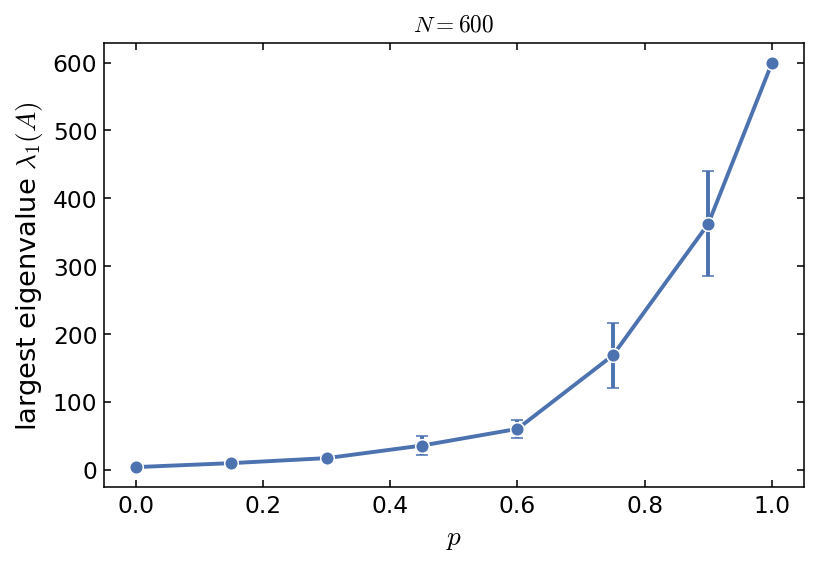

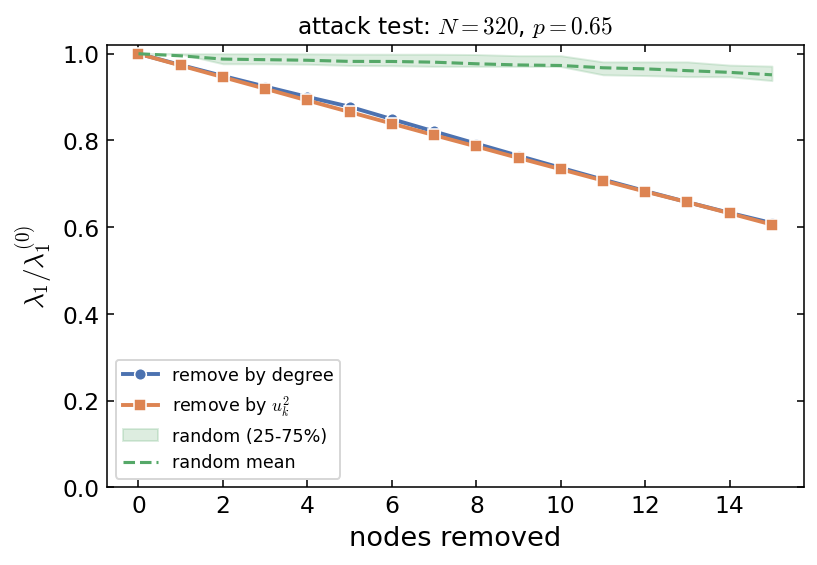

In [66]:
def largest_eigpair(G: nx.Graph):
    n = G.number_of_nodes()
    if n == 0:
        return np.nan, np.array([])
    if G.number_of_edges() == 0:
        return 0.0, np.ones(n) / np.sqrt(max(n, 1))
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)
    vals, vecs = eigsh(A, k=1, which="LA")
    return float(vals[0]), np.asarray(vecs[:, 0])


def simulate_lambda_vs_p(N, p_values, n_real, seed0=BASE_SEED):
    p_values = tuple(float(p) for p in p_values)
    params = {"N": N, "p_values": p_values, "n_real": n_real, "seed0": seed0}

    def _compute():
        means, cis = [], []
        for j, p in enumerate(p_values):
            vals = []
            for s in range(n_real):
                G = grow_all_or_none(N, p, seed=seed0 + 10_000 * j + s)
                lam, _ = largest_eigpair(G)
                vals.append(lam)
            vals = np.array(vals, dtype=float)
            m, ci = mean_ci(vals)
            means.append(m)
            cis.append(ci)
        return {"p": np.array(p_values), "mean": np.array(means), "ci": np.array(cis)}

    return cached_compute("lambda_vs_p_aon", params, _compute)


def remove_one_node_greedy(G: nx.Graph, strategy: str, rng=None):
    if strategy == "degree":
        deg = dict(G.degree())
        node = max(deg, key=lambda u: (deg[u], -u if isinstance(u, int) else 0))
    elif strategy == "dynamical":
        _, u = largest_eigpair(G)
        nodes = list(G.nodes())
        scores = {node: float(abs(u[i]) ** 2) for i, node in enumerate(nodes)}
        node = max(scores, key=scores.get)
    elif strategy == "random":
        node = rng.choice(list(G.nodes()))
    else:
        raise ValueError(strategy)
    G.remove_node(node)


def attack_curve(G0: nx.Graph, strategy: str, n_remove: int, seed=0):
    G = G0.copy()
    lam0, _ = largest_eigpair(G)
    curve = [1.0]
    rng = np.random.default_rng(seed)
    for _ in range(n_remove):
        if G.number_of_nodes() <= 1:
            curve.append(0.0)
            continue
        remove_one_node_greedy(G, strategy, rng)
        lam, _ = largest_eigpair(G)
        curve.append(float(lam / lam0) if lam0 > 0 else 0.0)
    return np.arange(len(curve)), np.array(curve)


# --- Spectral radius vs p ---
lam = simulate_lambda_vs_p(CFG.N_lambda, CFG.p_lambda, CFG.n_real_lambda, seed0=BASE_SEED + 100_000)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.errorbar(lam["p"], lam["mean"], yerr=lam["ci"],
            fmt="o-", ms=7, mfc="#4C72B0", mec="white", mew=0.8,
            color="#4C72B0", lw=2.0, capsize=3)
ax.set_xlabel(r"$p$")
ax.set_ylabel(r"largest eigenvalue $\lambda_1(A)$")
ax.set_title(rf"$N={CFG.N_lambda}$", fontsize=12)
fig.tight_layout()
plt.show()

# --- Attack test ---
G_attack = grow_all_or_none(CFG.N_attack, CFG.p_attack, seed=BASE_SEED + 111_000)
x_deg, y_deg = attack_curve(G_attack, "degree", CFG.n_remove_attack, seed=BASE_SEED + 1)
x_dyn, y_dyn = attack_curve(G_attack, "dynamical", CFG.n_remove_attack, seed=BASE_SEED + 2)

rand_curves = []
for s in range(CFG.n_random_attack):
    _, y_rand = attack_curve(G_attack, "random", CFG.n_remove_attack, seed=BASE_SEED + 3 + s)
    rand_curves.append(y_rand)
rand_curves = np.array(rand_curves)
y_rand_mean = rand_curves.mean(axis=0)
y_rand_lo = np.quantile(rand_curves, 0.25, axis=0)
y_rand_hi = np.quantile(rand_curves, 0.75, axis=0)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(x_deg, y_deg, "o-", ms=6, mfc="#4C72B0", mec="white", mew=0.8,
        color="#4C72B0", lw=2.0, label="remove by degree")
ax.plot(x_dyn, y_dyn, "s-", ms=6, mfc="#DD8452", mec="white", mew=0.8,
        color="#DD8452", lw=2.0, label=r"remove by $u_k^2$")
ax.fill_between(x_deg, y_rand_lo, y_rand_hi, alpha=0.20, color="#55A868", label="random (25-75%)")
ax.plot(x_deg, y_rand_mean, "--", color="#55A868", lw=1.6, label="random mean")
ax.set_xlabel("nodes removed")
ax.set_ylabel(r"$\lambda_1 / \lambda_1^{(0)}$")
ax.set_ylim(0.0, 1.02)
ax.set_title(rf"attack test: $N={CFG.N_attack}$, $p={CFG.p_attack:.2f}$", fontsize=12)
ax.legend(frameon=True, fancybox=True, edgecolor="0.8", fontsize=9)
fig.tight_layout()
plt.show()
